# Hyperparameter Selection: Aggregate Storms

Notebook to explore the effect of different hyperparameter choices in the clustering algorithm on aggregate statistics of storms found in various papers. Used as a sort of sanity check.

Jimmy Butler, April 2025

In [315]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import seaborn as sns
import os
from pathlib import Path

curwd = os.getcwd()
os.chdir(str(Path(os.getcwd()).parents[1]) + '/scripts/')
import utils
os.chdir(curwd)

In [316]:
def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

## Default Parameters

In [317]:
load_path = "/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/all_years/seed_12345eps_time_12eps_space_0.5rep_pts_10min_pts_5/storm_df.h5"
df = pd.read_hdf(load_path)

In [318]:
df['duration'] = df['data_array'].apply(compute_duration)
df['start_date'] = df['data_array'].apply(add_start_date)
df['end_date'] = df['data_array'].apply(add_end_date)

### Number of Storms

In [319]:
landfalling_df = df[df.is_landfalling]
num_non_landfalling = df.groupby(df.start_date.dt.year, as_index=False).size()
num_landfalling = landfalling_df.groupby(landfalling_df.start_date.dt.year, as_index=False).size()

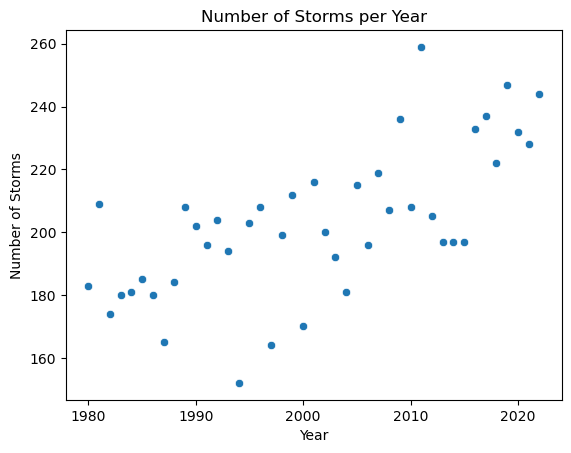

In [320]:
sns.scatterplot(data=num_non_landfalling, x='start_date', y='size')
plt.title('Number of Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Text(0, 0.5, 'Number of Storms')

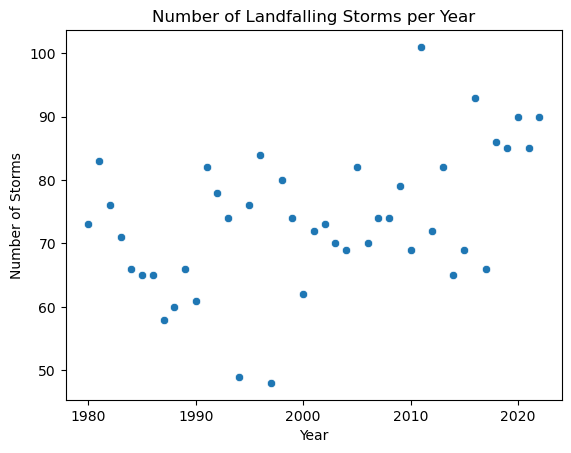

In [321]:
sns.scatterplot(data=num_landfalling, x='start_date', y='size')
plt.title('Number of Landfalling Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms')

### Histogram of Storm Centers at 55 S

In [322]:
def average_longitude(da, lat):
    region_mask = da.where((da.lat == -55), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat','lon'])]
    region_mask = region_mask.sel(time=times)
    indices = np.argwhere(region_mask.to_numpy())
    lons = region_mask.lon[indices[:,2]].to_numpy()
    lats = region_mask.lat[indices[:,1]].to_numpy()
    pt_df = pd.DataFrame({'lats': lats, 'lons':lons})
    pt_df.name = 'hello!'

    return utils.average_angle(pt_df)[2]
    

In [323]:
df['avg_longitude'] = df['data_array'].apply(lambda x: average_longitude(x,lat=-55))
latitude_intersections = df[df.avg_longitude.notnull()]

In [324]:
def assign_region(lon):
    if lon >= -165 and lon <= -45:
        return 'West'
    elif lon > -45 and lon <= 75:
        return 'East 1'
    else:
        return 'East 2'

In [325]:
latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)

/tmp/ipykernel_3227450/97374176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)


<Axes: xlabel='avg_longitude', ylabel='Count'>

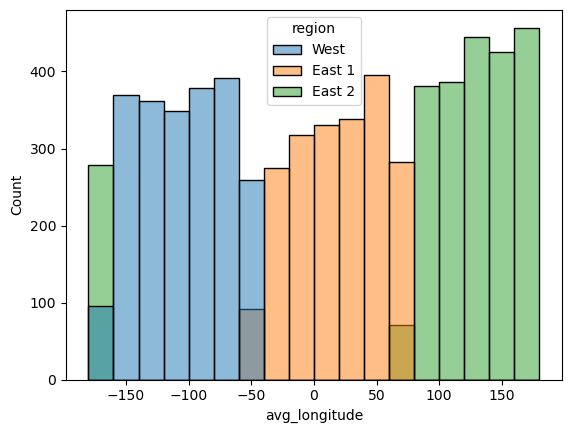

In [326]:
sns.histplot(data=latitude_intersections, x='avg_longitude', hue='region')

### Durations and Counts in Marie Byrd Land/Amundsen Sea Embayment (Maclennan 2023)

In [327]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration
    

In [328]:
df['in_MBL_ASE'] = df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))

In [329]:
mbl_ase_storms = df[df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year, as_index=False).size()

/tmp/ipykernel_3227450/2362766704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))


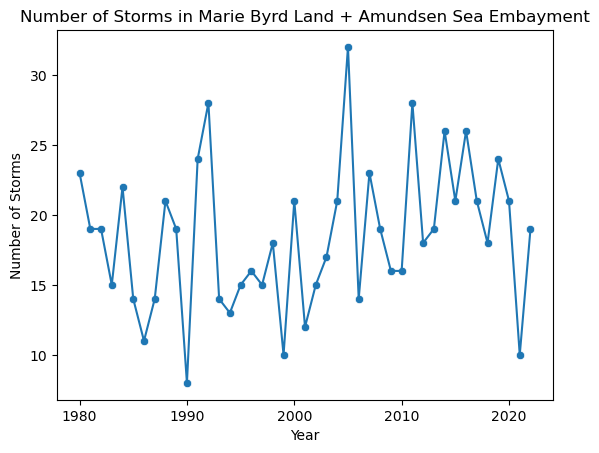

In [330]:
sns.lineplot(data=num_storms, x='start_date', y='size')
sns.scatterplot(data=num_storms, x='start_date', y='size')
plt.title('Number of Storms in Marie Byrd Land + Amundsen Sea Embayment')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Number of storms per year: 17 on average, plus or minus 5.

In [331]:
num_storms['size'].mean()

np.float64(18.488372093023255)

In [332]:
num_storms['size'].std()

np.float64(5.261595326710313)

In [333]:
mbl_ase_storms_mean_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
mbl_ase_storms_sd_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.std()/np.timedelta64(1, 'h')
mbl_ase_storms_plussd_durations = mbl_ase_storms_mean_durations + mbl_ase_storms_sd_durations
mbl_ase_storms_minussd_durations = mbl_ase_storms_mean_durations - mbl_ase_storms_sd_durations
mbl_ase_storms_max_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.max()/np.timedelta64(1, 'h')
mbl_ase_storms_min_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.min()/np.timedelta64(1, 'h')

durations_df = pd.concat({'mean': mbl_ase_storms_mean_durations, 
                          'plus_sd':mbl_ase_storms_plussd_durations, 
                          'minus_sd': mbl_ase_storms_minussd_durations, 
                          'max': mbl_ase_storms_max_durations, 
                          'min': mbl_ase_storms_min_durations}, axis=1)
durations_df = durations_df.reset_index()

<Axes: xlabel='start_date', ylabel='mean'>

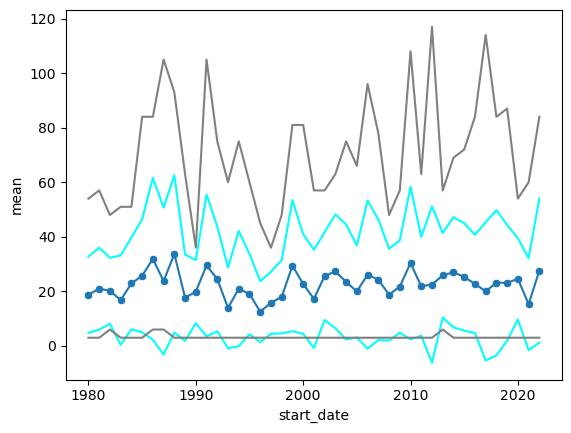

In [334]:
sns.scatterplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='plus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='minus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='max', color='gray')
sns.lineplot(data=durations_df, x='start_date', y='min', color='gray')

## Rep Pts Variations

### rep_pts = 20

In [335]:
load_path = "/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/all_years/seed_12345eps_time_12eps_space_0.5rep_pts_20min_pts_5/storm_df.h5"
df = pd.read_hdf(load_path)

In [336]:
df['duration'] = df['data_array'].apply(compute_duration)
df['start_date'] = df['data_array'].apply(add_start_date)
df['end_date'] = df['data_array'].apply(add_end_date)

### Number of Storms

In [337]:
landfalling_df = df[df.is_landfalling]
num_non_landfalling = df.groupby(df.start_date.dt.year, as_index=False).size()
num_landfalling = landfalling_df.groupby(landfalling_df.start_date.dt.year, as_index=False).size()

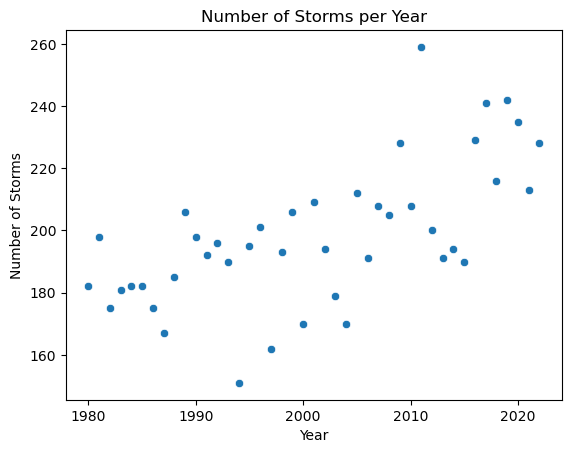

In [338]:
sns.scatterplot(data=num_non_landfalling, x='start_date', y='size')
plt.title('Number of Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Text(0, 0.5, 'Number of Storms')

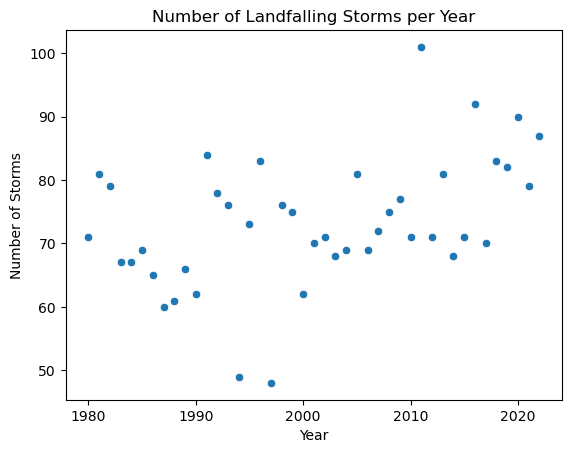

In [339]:
sns.scatterplot(data=num_landfalling, x='start_date', y='size')
plt.title('Number of Landfalling Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms')

### Histogram of Storm Centers at 55 S

In [340]:
def average_longitude(da, lat):
    region_mask = da.where((da.lat == -55), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat','lon'])]
    region_mask = region_mask.sel(time=times)
    indices = np.argwhere(region_mask.to_numpy())
    lons = region_mask.lon[indices[:,2]].to_numpy()
    lats = region_mask.lat[indices[:,1]].to_numpy()
    pt_df = pd.DataFrame({'lats': lats, 'lons':lons})
    pt_df.name = 'hello!'

    return utils.average_angle(pt_df)[2]
    

In [341]:
df['avg_longitude'] = df['data_array'].apply(lambda x: average_longitude(x,lat=-55))
latitude_intersections = df[df.avg_longitude.notnull()]

In [342]:
def assign_region(lon):
    if lon >= -165 and lon <= -45:
        return 'West'
    elif lon > -45 and lon <= 75:
        return 'East 1'
    else:
        return 'East 2'

In [343]:
latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)

/tmp/ipykernel_3227450/97374176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)


<Axes: xlabel='avg_longitude', ylabel='Count'>

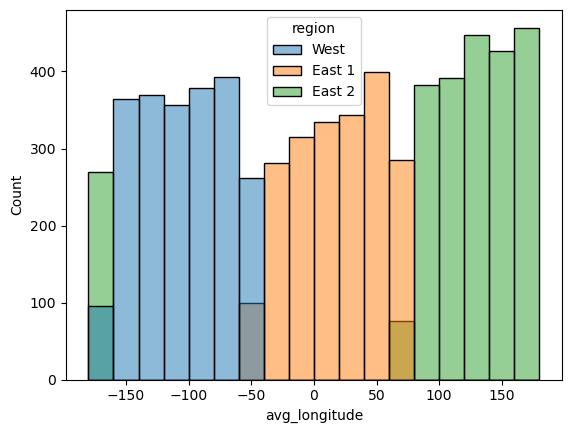

In [344]:
sns.histplot(data=latitude_intersections, x='avg_longitude', hue='region')

### Durations and Counts in Marie Byrd Land/Amundsen Sea Embayment (Maclennan 2023)

In [345]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration
    

In [346]:
df['in_MBL_ASE'] = df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))

In [347]:
mbl_ase_storms = df[df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year, as_index=False).size()

/tmp/ipykernel_3227450/2362766704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))


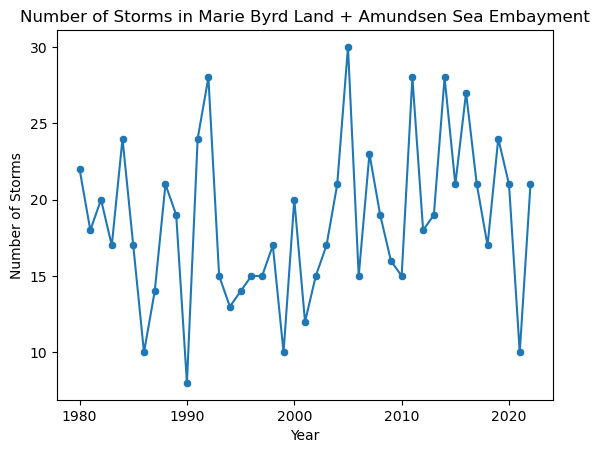

In [348]:
sns.lineplot(data=num_storms, x='start_date', y='size')
sns.scatterplot(data=num_storms, x='start_date', y='size')
plt.title('Number of Storms in Marie Byrd Land + Amundsen Sea Embayment')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Number of storms per year: 17 on average, plus or minus 5.

In [349]:
num_storms['size'].mean()

np.float64(18.58139534883721)

In [350]:
num_storms['size'].std()

np.float64(5.2835438960874175)

In [351]:
mbl_ase_storms_mean_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
mbl_ase_storms_sd_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.std()/np.timedelta64(1, 'h')
mbl_ase_storms_plussd_durations = mbl_ase_storms_mean_durations + mbl_ase_storms_sd_durations
mbl_ase_storms_minussd_durations = mbl_ase_storms_mean_durations - mbl_ase_storms_sd_durations
mbl_ase_storms_max_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.max()/np.timedelta64(1, 'h')
mbl_ase_storms_min_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.min()/np.timedelta64(1, 'h')

durations_df = pd.concat({'mean': mbl_ase_storms_mean_durations, 
                          'plus_sd':mbl_ase_storms_plussd_durations, 
                          'minus_sd': mbl_ase_storms_minussd_durations, 
                          'max': mbl_ase_storms_max_durations, 
                          'min': mbl_ase_storms_min_durations}, axis=1)
durations_df = durations_df.reset_index()

<Axes: xlabel='start_date', ylabel='mean'>

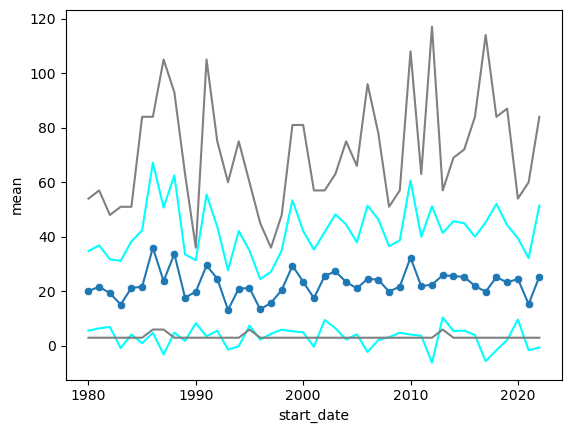

In [352]:
sns.scatterplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='plus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='minus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='max', color='gray')
sns.lineplot(data=durations_df, x='start_date', y='min', color='gray')

## Time Epsilon Variations

### $\epsilon_{time} = 16$

In [353]:
load_path = "/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/all_years/seed_12345eps_time_16eps_space_0.5rep_pts_10min_pts_5/storm_df.h5"
df = pd.read_hdf(load_path)

In [354]:
df['duration'] = df['data_array'].apply(compute_duration)
df['start_date'] = df['data_array'].apply(add_start_date)
df['end_date'] = df['data_array'].apply(add_end_date)

### Number of Storms

In [355]:
landfalling_df = df[df.is_landfalling]
num_non_landfalling = df.groupby(df.start_date.dt.year, as_index=False).size()
num_landfalling = landfalling_df.groupby(landfalling_df.start_date.dt.year, as_index=False).size()

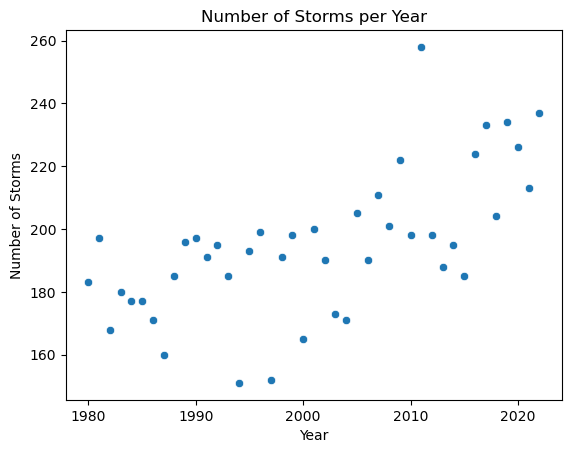

In [356]:
sns.scatterplot(data=num_non_landfalling, x='start_date', y='size')
plt.title('Number of Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Text(0, 0.5, 'Number of Storms')

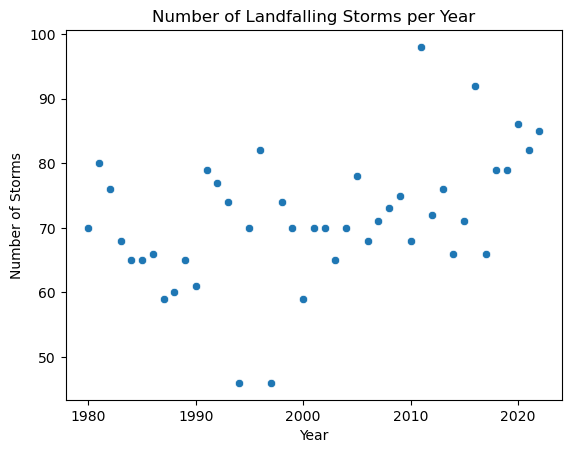

In [357]:
sns.scatterplot(data=num_landfalling, x='start_date', y='size')
plt.title('Number of Landfalling Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms')

### Histogram of Storm Centers at 55 S

In [358]:
def average_longitude(da, lat):
    region_mask = da.where((da.lat == -55), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat','lon'])]
    region_mask = region_mask.sel(time=times)
    indices = np.argwhere(region_mask.to_numpy())
    lons = region_mask.lon[indices[:,2]].to_numpy()
    lats = region_mask.lat[indices[:,1]].to_numpy()
    pt_df = pd.DataFrame({'lats': lats, 'lons':lons})
    pt_df.name = 'hello!'

    return utils.average_angle(pt_df)[2]
    

In [359]:
df['avg_longitude'] = df['data_array'].apply(lambda x: average_longitude(x,lat=-55))
latitude_intersections = df[df.avg_longitude.notnull()]

In [360]:
def assign_region(lon):
    if lon >= -165 and lon <= -45:
        return 'West'
    elif lon > -45 and lon <= 75:
        return 'East 1'
    else:
        return 'East 2'

In [361]:
latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)

/tmp/ipykernel_3227450/97374176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)


<Axes: xlabel='avg_longitude', ylabel='Count'>

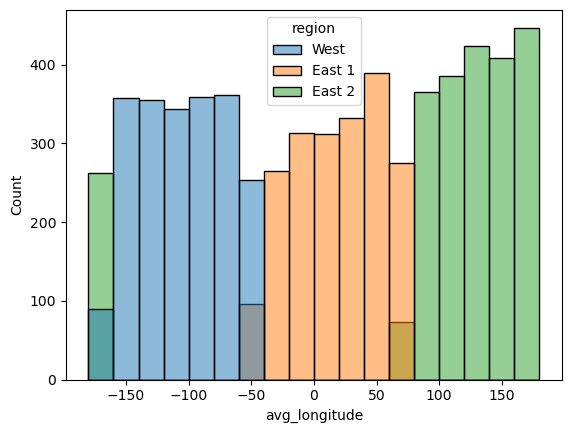

In [362]:
sns.histplot(data=latitude_intersections, x='avg_longitude', hue='region')

### Durations and Counts in Marie Byrd Land/Amundsen Sea Embayment (Maclennan 2023)

In [363]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration
    

In [364]:
df['in_MBL_ASE'] = df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))

In [365]:
mbl_ase_storms = df[df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year, as_index=False).size()

/tmp/ipykernel_3227450/2362766704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))


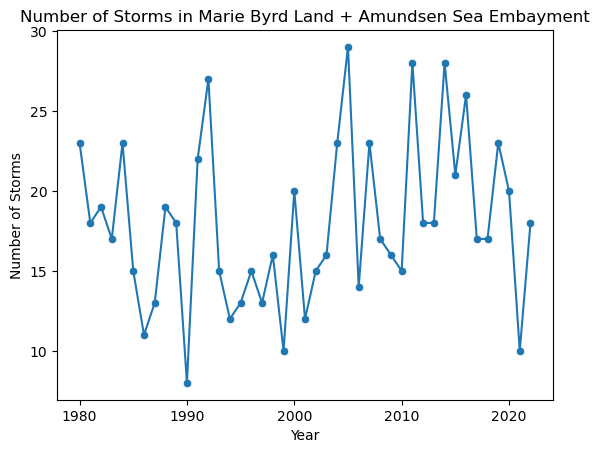

In [366]:
sns.lineplot(data=num_storms, x='start_date', y='size')
sns.scatterplot(data=num_storms, x='start_date', y='size')
plt.title('Number of Storms in Marie Byrd Land + Amundsen Sea Embayment')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Number of storms per year: 17 on average, plus or minus 5.

In [367]:
num_storms['size'].mean()

np.float64(17.930232558139537)

In [368]:
num_storms['size'].std()

np.float64(5.17960905326155)

In [369]:
mbl_ase_storms_mean_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
mbl_ase_storms_sd_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.std()/np.timedelta64(1, 'h')
mbl_ase_storms_plussd_durations = mbl_ase_storms_mean_durations + mbl_ase_storms_sd_durations
mbl_ase_storms_minussd_durations = mbl_ase_storms_mean_durations - mbl_ase_storms_sd_durations
mbl_ase_storms_max_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.max()/np.timedelta64(1, 'h')
mbl_ase_storms_min_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.min()/np.timedelta64(1, 'h')

durations_df = pd.concat({'mean': mbl_ase_storms_mean_durations, 
                          'plus_sd':mbl_ase_storms_plussd_durations, 
                          'minus_sd': mbl_ase_storms_minussd_durations, 
                          'max': mbl_ase_storms_max_durations, 
                          'min': mbl_ase_storms_min_durations}, axis=1)
durations_df = durations_df.reset_index()

<Axes: xlabel='start_date', ylabel='mean'>

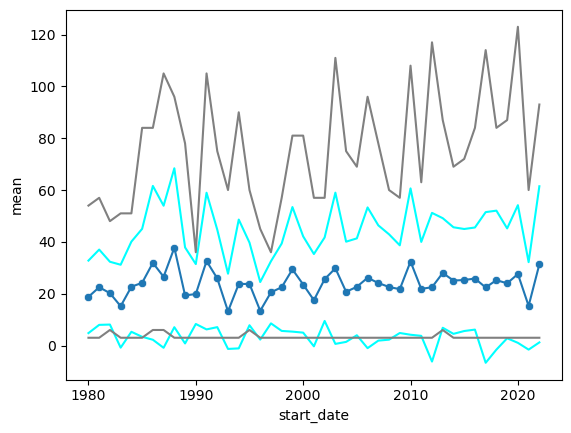

In [370]:
sns.scatterplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='plus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='minus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='max', color='gray')
sns.lineplot(data=durations_df, x='start_date', y='min', color='gray')

### $\epsilon_{time} = 18$

In [371]:
load_path = "/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/all_years/seed_12345eps_time_18eps_space_0.5rep_pts_10min_pts_5/storm_df.h5"
df = pd.read_hdf(load_path)

In [372]:
df['duration'] = df['data_array'].apply(compute_duration)
df['start_date'] = df['data_array'].apply(add_start_date)
df['end_date'] = df['data_array'].apply(add_end_date)

### Number of Storms

In [373]:
landfalling_df = df[df.is_landfalling]
num_non_landfalling = df.groupby(df.start_date.dt.year, as_index=False).size()
num_landfalling = landfalling_df.groupby(landfalling_df.start_date.dt.year, as_index=False).size()

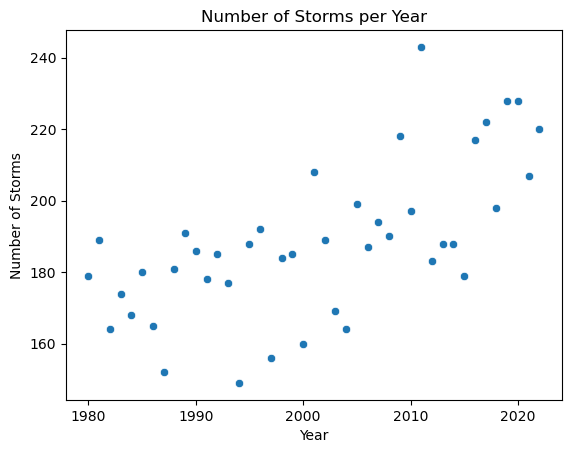

In [374]:
sns.scatterplot(data=num_non_landfalling, x='start_date', y='size')
plt.title('Number of Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Text(0, 0.5, 'Number of Storms')

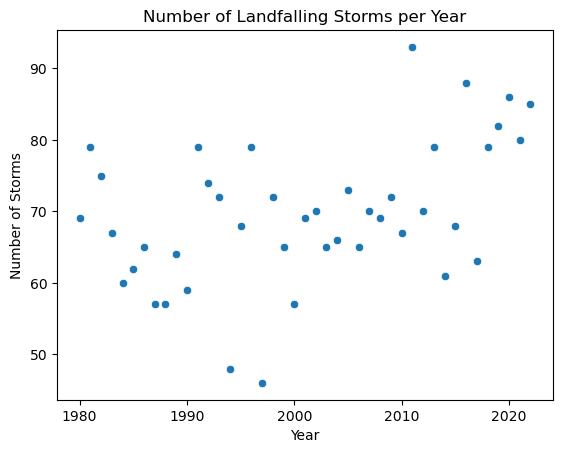

In [375]:
sns.scatterplot(data=num_landfalling, x='start_date', y='size')
plt.title('Number of Landfalling Storms per Year')
plt.xlabel('Year')
plt.ylabel('Number of Storms')

### Histogram of Storm Centers at 55 S

In [376]:
def average_longitude(da, lat):
    region_mask = da.where((da.lat == -55), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat','lon'])]
    region_mask = region_mask.sel(time=times)
    indices = np.argwhere(region_mask.to_numpy())
    lons = region_mask.lon[indices[:,2]].to_numpy()
    lats = region_mask.lat[indices[:,1]].to_numpy()
    pt_df = pd.DataFrame({'lats': lats, 'lons':lons})
    pt_df.name = 'hello!'

    return utils.average_angle(pt_df)[2]
    

In [377]:
df['avg_longitude'] = df['data_array'].apply(lambda x: average_longitude(x,lat=-55))
latitude_intersections = df[df.avg_longitude.notnull()]

In [378]:
def assign_region(lon):
    if lon >= -165 and lon <= -45:
        return 'West'
    elif lon > -45 and lon <= 75:
        return 'East 1'
    else:
        return 'East 2'

In [379]:
latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)

/tmp/ipykernel_3227450/97374176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude_intersections['region'] = latitude_intersections['avg_longitude'].apply(assign_region)


<Axes: xlabel='avg_longitude', ylabel='Count'>

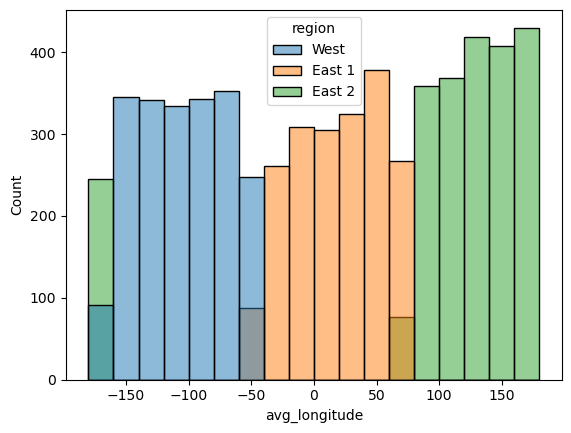

In [380]:
sns.histplot(data=latitude_intersections, x='avg_longitude', hue='region')

### Durations and Counts in Marie Byrd Land/Amundsen Sea Embayment (Maclennan 2023)

In [381]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & (da.lat >= lat_low) & (da.lon <= lon_high) & (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration
    

In [382]:
df['in_MBL_ASE'] = df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))

In [383]:
mbl_ase_storms = df[df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year, as_index=False).size()

/tmp/ipykernel_3227450/2362766704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))


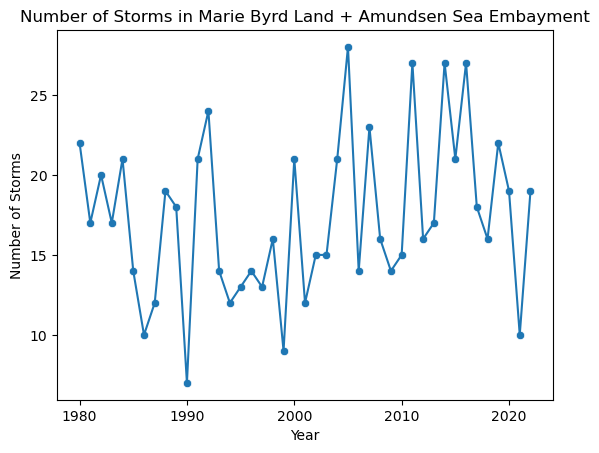

In [384]:
sns.lineplot(data=num_storms, x='start_date', y='size')
sns.scatterplot(data=num_storms, x='start_date', y='size')
plt.title('Number of Storms in Marie Byrd Land + Amundsen Sea Embayment')
plt.xlabel('Year')
plt.ylabel('Number of Storms');

Number of storms per year: 17 on average, plus or minus 5.

In [385]:
num_storms['size'].mean()

np.float64(17.348837209302324)

In [386]:
num_storms['size'].std()

np.float64(5.079762465998137)

In [387]:
mbl_ase_storms_mean_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
mbl_ase_storms_sd_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.std()/np.timedelta64(1, 'h')
mbl_ase_storms_plussd_durations = mbl_ase_storms_mean_durations + mbl_ase_storms_sd_durations
mbl_ase_storms_minussd_durations = mbl_ase_storms_mean_durations - mbl_ase_storms_sd_durations
mbl_ase_storms_max_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.max()/np.timedelta64(1, 'h')
mbl_ase_storms_min_durations = mbl_ase_storms.groupby(mbl_ase_storms.start_date.dt.year).duration_MBL_ASE.min()/np.timedelta64(1, 'h')

durations_df = pd.concat({'mean': mbl_ase_storms_mean_durations, 
                          'plus_sd':mbl_ase_storms_plussd_durations, 
                          'minus_sd': mbl_ase_storms_minussd_durations, 
                          'max': mbl_ase_storms_max_durations, 
                          'min': mbl_ase_storms_min_durations}, axis=1)
durations_df = durations_df.reset_index()

<Axes: xlabel='start_date', ylabel='mean'>

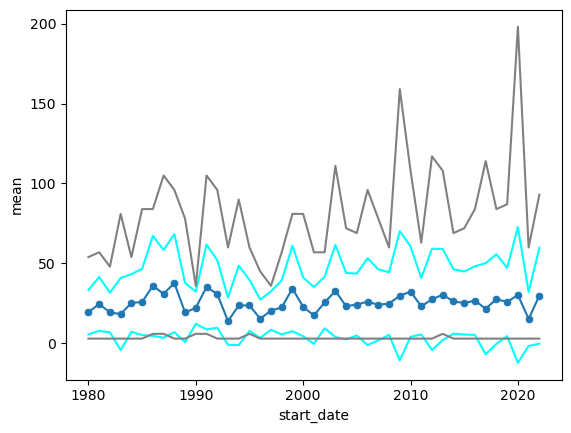

In [388]:
sns.scatterplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='mean')
sns.lineplot(data=durations_df, x='start_date', y='plus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='minus_sd', color='cyan')
sns.lineplot(data=durations_df, x='start_date', y='max', color='gray')
sns.lineplot(data=durations_df, x='start_date', y='min', color='gray')